In [74]:
import numpy as np

class GradientRegressor:
  #constructor
  def __init__(self):
    self.m = 0
    self.b = 0

  def fit(self,X_train,y_train):
    self.m = 0
    self.b = 0
    lr = 0.001
    epochs = 1000

    for i in range(epochs):
       #Calculate partial derivative
        dl_db = -2 * np.mean(y_train - (self.m*X_train + self.b))
        dl_dm = (-2) * np.mean(X_train * (y_train - (self.m*X_train + self.b))) # here using mean instead of sum to avg gradient
        #Update parameters
        self.m = self.m - (lr*dl_dm)
        self.b = self.b - (lr*dl_db)

  def predict(self,X_train):
    return self.m*X_train + self.b

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [76]:
# Step 2: Generate Sample Data (100 observations)
np.random.seed(42)
X = 5 * np.random.rand(100, 1) + 1   # Study Hours between 1 and 6
y = 15 + 8 * X + np.random.randn(100, 1) * 3  # Marks with noisee

#  Convert to DataFrame
df = pd.DataFrame({'Study Hours': X.flatten(), 'Marks': y.flatten()})
print(df.head())

   Study Hours      Marks
0     2.872701  38.242746
1     5.753572  60.131550
2     4.659970  52.555040
3     3.993292  40.983633
4     1.780093  28.581730


In [77]:
df.shape

(100, 2)

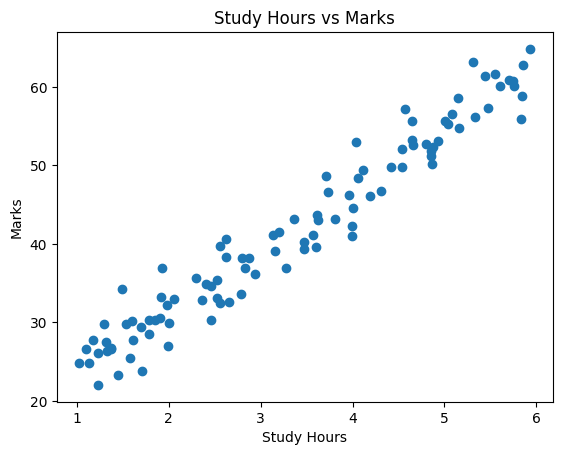

In [78]:
plt.scatter(df['Study Hours'], df['Marks'])
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Study Hours vs Marks')
plt.show()

In [79]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['Study Hours'], df['Marks'], test_size=0.2, random_state=42)

In [80]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape )

(80,)
(20,)
(80,)
(20,)


In [81]:
gr = GradientRegressor()

In [82]:
gr.fit(X_train.values, y_train.values)

In [83]:
gr.predict(2)

np.float64(26.508820702759955)

In [84]:
from sklearn.metrics import mean_absolute_error
y_pred = gr.predict(X_test.values)
mse = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mse}")

Mean Absolute Error: 4.612873177963947


In [85]:
from sklearn.metrics import r2_score
y_pred = gr.predict(X_test.values)
r2 = r2_score(y_test, y_pred)
print(f"R-squared Score: {r2}")

R-squared Score: 0.8250399287690652
